In [6]:
import os
from glob import glob
import numpy as np
import random
import matplotlib.pyplot as plt
from PIL import Image
from tqdm import tqdm
from utils import get_dataset_name, get_dataset_json
import nibabel as nib

  0%|          | 0/5635 [00:00<?, ?it/s]

  0%|          | 24/5635 [00:00<03:43, 25.09it/s]


img: (420, 580)
label: (420, 580) [0 1]


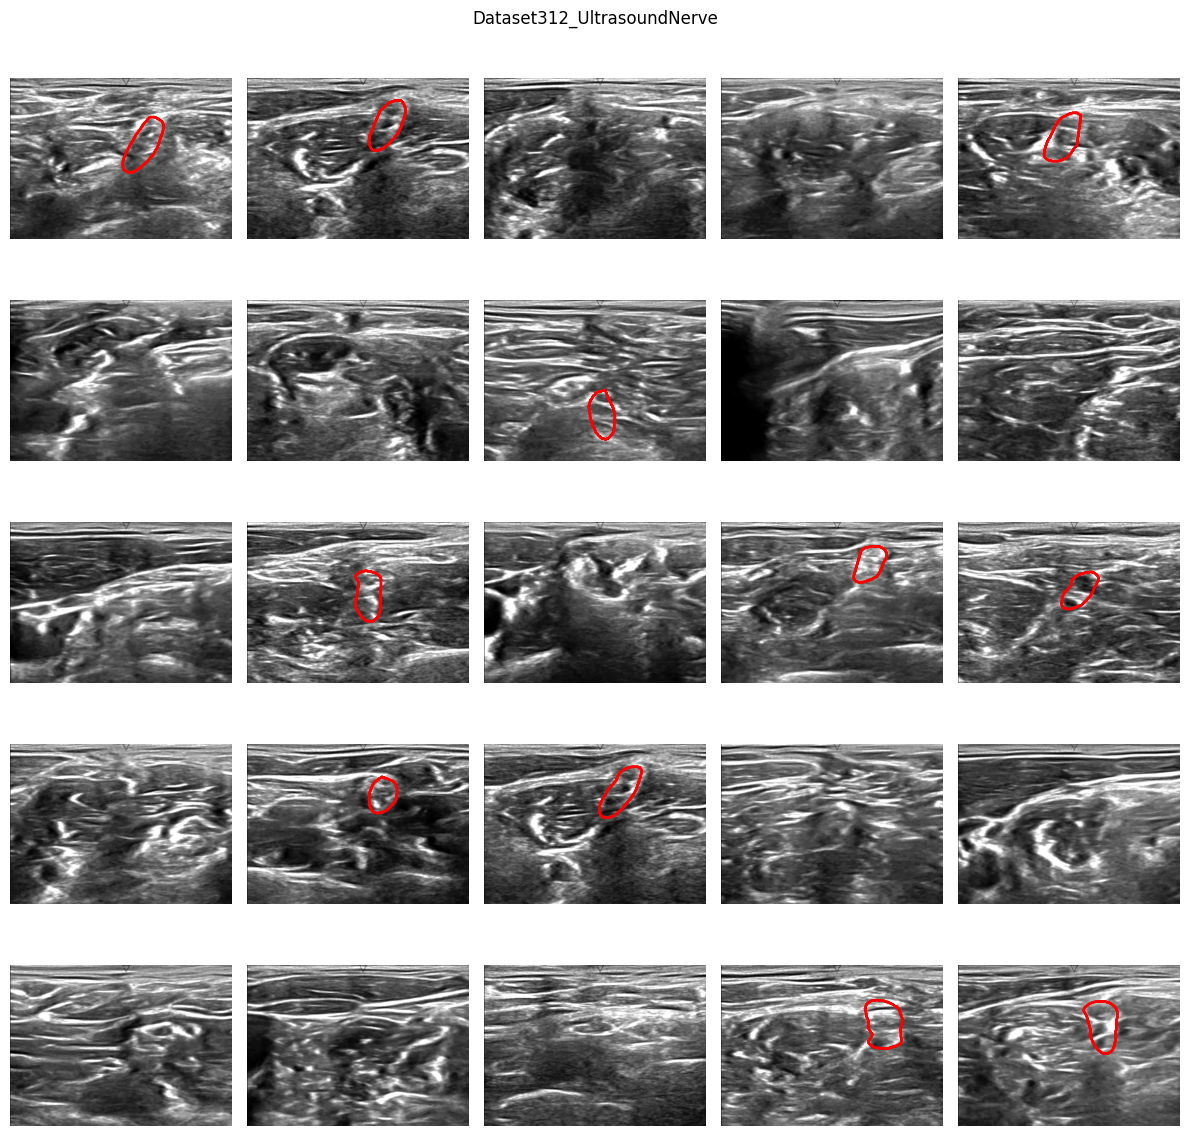

In [51]:
data_dir = "data/nnUNet_raw"
dataset_id = 312
dataset = get_dataset_name(dataset_id)
file_ending = get_dataset_json(dataset_id)["file_ending"]
dst_dir = f"debug/eda"
os.makedirs(dst_dir, exist_ok=True)
imgs = glob(os.path.join(data_dir, dataset, "imagesTr", f"*_0000{file_ending}"))
random.shuffle(imgs)

num_samples = 25
num_cols = 5
num_rows = num_samples // num_cols
plt.figure(figsize=(12, 12))
for i, img_path in enumerate(tqdm(imgs)):
    other_chs = [ch for ch in glob(img_path.replace("_0000.", "_*.")) if ch != img_path]
    label_path = img_path.replace("imagesTr", "labelsTr").replace("_0000.", ".")
    if file_ending == ".nii.gz":
        img = nib.load(img_path).get_fdata()
        label = nib.load(label_path).get_fdata()
    else:
        img = np.array(Image.open(img_path))
        label = np.array(Image.open(label_path))
    
    if other_chs:
        # Stack other channels onto img if they exist (as additional channels)
        other_arrays = [np.array(Image.open(ch)) for ch in sorted(other_chs)]
        img = np.concatenate([img[..., None]] + [arr[..., None] for arr in other_arrays], axis=-1)
    
    if img.ndim == 3 and img.shape[-1] > 3:
        idx = random.randint(0, img.shape[-1] - 1)
        img = img[..., idx]
        label = label[..., idx]
    plt.subplot(num_rows, num_cols, i + 1)
    plt.imshow(img, cmap='gray' if img.ndim == 2 else None)
    if np.unique(label).size > 2 or dataset_id == 309:
        masked_label = np.ma.masked_where(label == 0, label)
        plt.imshow(masked_label, cmap='tab10', interpolation='nearest')
    else:
        plt.contour(label, colors="red")
    plt.axis("off")
    if i == num_samples - 1:
        break

print("img:", img.shape)
print("label:", label.shape, np.unique(label))
plt.suptitle(f"{dataset}")
plt.tight_layout()
plt.savefig(os.path.join(dst_dir, f"{dataset}.svg"), format="svg", bbox_inches="tight")
plt.show()